[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Advanced-Time-Series/blob/main/Quantlets/Ch_06/ATS_ch6_seminar/ATS_ch6_seminar.ipynb)

# Advanced Time Series Analysis and Forecasting — Seminar 6: State space models and Bayesian filtering

*Seminar notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- The seminar comes before Lecture 6; the slides give the definitions ("What you need today").
- [Solved] tasks: full solution here and in the slides; [Proposed] tasks: write your own code in the empty cell.
- The seminar is for practice and is not graded; the solutions of [Proposed] tasks are discussed in class.

> Quantlet `ATS_ch6_seminar`: student version of the Seminar 6 notebook. Solved exercises (A1, A3, A5, A7, A9, B1, B3) are shown with code and output; the proposed exercises (A2, A4, A6, A8, A10, B2, B4, B5, C1, C2) are not solved here (an empty code cell where they need code).

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/ATS/Chapter_6'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [ ]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [ ]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import ats_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the ATS repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Advanced-Time-Series/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the ATS repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Seminar functions

- The state space engine, the samplers, the SV tools and the trend–cycle models of Chapter 6, the data loaders and the functions of the solved tasks.

In [ ]:
import time
from scipy import linalg
SEED = 2026
LOG2PI = np.log(2 * np.pi)
KSC_P = np.array([0.0073, 0.10556, 2e-05, 0.04395, 0.34001, 0.24566, 0.2575])
KSC_M = np.array([-10.12999, -3.97281, -8.56686, 2.77786, 0.61942, 1.79518, -1.08819])
KSC_V = np.array([5.79596, 2.61369, 5.1795, 0.16735, 0.64009, 0.34023, 1.26261])
SV = {'start': '2016-01-01', 'end': '2026-09-18', 'offset': 0.001}
MNZ = {'start': '1947-01-01', 'end': '1998-04-01'}
UCSV = {'gamma': 0.2, 'start_us': '1953-01-01', 'start_ro': '2001-01-01'}
TVP = {'start': '2005-08-01'}
DFM_SERIES = {'INDPRO': 'industrial production', 'PAYEMS': 'payroll employment', 'W875RX1': 'real personal income less transfers', 'CMRMTSPL': 'real manufacturing and trade sales'}
_sv_cache = {}
A1Y, A1E, A1H = np.array([2.0, 3.0, 2.5]), 1.0, 0.5
A4 = {'n': 50, 'a0': 2.5, 'b0': 0.25, 'sse': 40.0, 'ssh': 6.2}
A5 = {'phi': 0.98, 's': 0.15}
A7H, A7Y, A7U = np.array([-1.0, 0.0, 0.5, 1.5]), 2.0, 0.3
A8X, A8Y, A8E, A8H = np.array([0.0, 1.0, 2.0, 3.0]), 4.0, 0.5, 0.25
A9 = {'phi': 0.35, 'mu': 0.8, 'dy': 2.0}
A10Q = 0.5
_cache = {}


def save(name, save_it=True):
    st.check_no_grey(plt.gcf())
    if save_it:
        st.save_fig(name)
    else:
        plt.show()
        plt.close()


def ssm(Z, T, R, Q, H, a1=None, P1=None, Pinf=None, c=None):
    """A time-invariant state space model (Durbin and Koopman 2012 notation), univariate observation:
        y_t = Z_t alpha_t + eps_t,          eps_t ~ N(0, H)
        alpha_{t+1} = c + T alpha_t + R eta_t,   eta_t ~ N(0, Q)
        alpha_1 ~ N(a1, P1 + kappa * Pinf), kappa -> infinity (exact diffuse part Pinf).
    Z may be a vector (m,) or a matrix (n, m) of time-varying rows (regressions)."""
    T = np.atleast_2d(np.asarray(T, float))
    m = T.shape[0]
    R = np.atleast_2d(np.asarray(R, float)).reshape(m, -1)
    Q = np.atleast_2d(np.asarray(Q, float))
    return dict(Z=np.asarray(Z, float), T=T, R=R, Q=Q, RQR=R @ Q @ R.T, H=float(H),
                a1=np.zeros(m) if a1 is None else np.asarray(a1, float),
                P1=np.zeros((m, m)) if P1 is None else np.atleast_2d(np.asarray(P1, float)),
                Pinf=np.zeros((m, m)) if Pinf is None else np.atleast_2d(np.asarray(Pinf, float)),
                c=np.zeros(m) if c is None else np.asarray(c, float))


def _zrow(mod, t):
    Z = mod['Z']
    return Z[t] if Z.ndim == 2 else Z


def kalman_filter(y, mod, tol=1e-8):
    """Kalman filter with exact diffuse initialisation (Koopman 1997; Durbin and Koopman 2012, Section 5.2) for a
    univariate observation. Missing values (NaN) skip the update. Returns predicted states a_t, P_t (P_*), the
    diffuse parts, innovations v_t, variances F_t and the diffuse log-likelihood (Durbin and Koopman 2012, eq. 7.4)."""
    y = np.asarray(y, float)
    n, m = len(y), mod['T'].shape[0]
    T, RQR, H, c = mod['T'], mod['RQR'], mod['H'], mod['c']
    a, P, Pi = mod['a1'].copy(), mod['P1'].copy(), mod['Pinf'].copy()
    out = dict(a=np.zeros((n, m)), P=np.zeros((n, m, m)), Pinf=np.zeros((n, m, m)), v=np.full(n, np.nan), att=np.zeros((n, m)),
               F=np.full(n, np.nan), Finf=np.zeros(n), K0=np.zeros((n, m)), K1=np.zeros((n, m)),
               ll=np.zeros(n), diffuse=np.zeros(n, bool))
    d = 0
    for t in range(n):
        Z = _zrow(mod, t)
        out['a'][t], out['P'][t], out['Pinf'][t] = a, P, Pi
        is_diff = np.abs(Pi).max() > tol
        out['diffuse'][t] = is_diff
        if np.isnan(y[t]):                       # missing observation: prediction only
            out['att'][t] = a
            a, P, Pi = c + T @ a, T @ P @ T.T + RQR, T @ Pi @ T.T
            continue
        v = y[t] - Z @ a
        Ms, Fs = P @ Z, Z @ P @ Z + H
        out['v'][t] = v
        if is_diff:
            Mi = Pi @ Z
            Fi = Z @ Mi
            out['Finf'][t] = Fi
            if Fi > tol:
                out['att'][t] = a + Mi * v / Fi
                F1, F2 = 1 / Fi, -Fs / Fi ** 2
                K0, K1 = T @ Mi * F1, T @ (Ms * F1 + Mi * F2)
                L0, L1 = T - np.outer(K0, Z), -np.outer(K1, Z)
                a = c + T @ a + K0 * v
                Pi, P = T @ Pi @ L0.T, T @ Pi @ L1.T + T @ P @ L0.T + RQR
                out['F'][t], out['K0'][t], out['K1'][t] = Fi, K0, K1
                out['ll'][t] = -0.5 * (LOG2PI + np.log(Fi))
            else:
                out['att'][t] = a + Ms * v / Fs
                K0 = T @ Ms / Fs
                L0 = T - np.outer(K0, Z)
                a = c + T @ a + K0 * v
                Pi, P = T @ Pi @ T.T, T @ P @ L0.T + RQR
                out['F'][t], out['K0'][t] = Fs, K0
                out['ll'][t] = -0.5 * (LOG2PI + np.log(Fs) + v ** 2 / Fs)
            d = t + 1
        else:
            out['att'][t] = a + Ms * v / Fs
            K = T @ Ms / Fs
            a = c + T @ a + K * v
            P = T @ P @ (T - np.outer(K, Z)).T + RQR
            out['F'][t], out['K0'][t] = Fs, K
            out['ll'][t] = -0.5 * (LOG2PI + np.log(Fs) + v ** 2 / Fs)
        P = 0.5 * (P + P.T)
    out['d'], out['loglik'] = d, float(out['ll'].sum())
    out['a_next'], out['P_next'] = a, P
    return out


def kalman_smoother(y, mod, kf=None, tol=1e-8):
    """State smoother with exact diffuse initialisation (Durbin and Koopman 2012, Section 5.3): backward recursions
    for r_t, N_t (and r^(1), N^(1), N^(2) in the diffuse period). Returns smoothed states and their variances."""
    y = np.asarray(y, float)
    kf = kf or kalman_filter(y, mod, tol)
    n, m = len(y), mod['T'].shape[0]
    T, H = mod['T'], mod['H']
    r0, r1 = np.zeros(m), np.zeros(m)
    N0, N1, N2 = np.zeros((m, m)), np.zeros((m, m)), np.zeros((m, m))
    ah, V = np.zeros((n, m)), np.zeros((n, m, m))
    for t in range(n - 1, -1, -1):
        Z = _zrow(mod, t)
        a, P, Pi, v = kf['a'][t], kf['P'][t], kf['Pinf'][t], kf['v'][t]
        if np.isnan(y[t]):
            r0, N0 = T.T @ r0, T.T @ N0 @ T
            if kf['diffuse'][t]:
                r1, N1, N2 = T.T @ r1, T.T @ N1 @ T, T.T @ N2 @ T
        elif not kf['diffuse'][t]:
            F = kf['F'][t]
            L = T - np.outer(kf['K0'][t], Z)
            r0 = Z * v / F + L.T @ r0
            N0 = np.outer(Z, Z) / F + L.T @ N0 @ L
        else:
            Fi = kf['Finf'][t]
            if Fi > tol:
                Fs = Z @ P @ Z + H
                F1, F2 = 1 / Fi, -Fs / Fi ** 2
                L0, L1 = T - np.outer(kf['K0'][t], Z), -np.outer(kf['K1'][t], Z)
                r1n = Z * v * F1 + L0.T @ r1 + L1.T @ r0
                r0n = L0.T @ r0
                N2n = (np.outer(Z, Z) * F2 + L0.T @ N2 @ L0 + L0.T @ N1 @ L1 + L1.T @ N1 @ L0
                       + L1.T @ N0 @ L1)
                N1n = np.outer(Z, Z) * F1 + L0.T @ N1 @ L0 + L1.T @ N0 @ L0 + L0.T @ N0 @ L1
                N0n = L0.T @ N0 @ L0
                r0, r1, N0, N1, N2 = r0n, r1n, N0n, N1n, N2n
            else:
                Fs = kf['F'][t]
                L0 = T - np.outer(kf['K0'][t], Z)
                r0 = Z * v / Fs + L0.T @ r0
                N0 = np.outer(Z, Z) / Fs + L0.T @ N0 @ L0
                r1, N1, N2 = T.T @ r1, T.T @ N1 @ L0, T.T @ N2 @ T
        if kf['diffuse'][t]:
            ah[t] = a + P @ r0 + Pi @ r1
            V[t] = P - P @ N0 @ P - (Pi @ N1 @ P).T - Pi @ N1 @ P - Pi @ N2 @ Pi
        else:
            ah[t] = a + P @ r0
            V[t] = P - P @ N0 @ P
    return dict(alpha=ah, V=V, kf=kf)


def big_kappa(mod, kappa):
    """The same model with the diffuse part replaced by kappa * Pinf (the approximate diffuse initialisation)."""
    m2 = dict(mod)
    m2['P1'] = mod['P1'] + kappa * mod['Pinf']
    m2['Pinf'] = np.zeros_like(mod['Pinf'])
    return m2


def local_level(s2eps, s2eta):
    """Local level model: y_t = mu_t + eps_t, mu_{t+1} = mu_t + eta_t, mu_1 diffuse."""
    return ssm([1.0], [[1.0]], [[1.0]], [[s2eta]], s2eps, Pinf=[[1.0]])


def num_hessian(f, x, h=1e-4):
    x = np.asarray(x, float)
    k = len(x)
    Hm = np.zeros((k, k))
    for i in range(k):
        for j in range(i, k):
            e1, e2 = np.zeros(k), np.zeros(k)
            e1[i], e2[j] = h, h
            Hm[i, j] = Hm[j, i] = (f(x + e1 + e2) - f(x + e1 - e2) - f(x - e1 + e2) + f(x - e1 - e2)) / (4 * h * h)
    return Hm


def fit_local_level(y):
    """Exact diffuse ML of the local level model with numpy: log-variances, BFGS from a grid start."""
    y = np.asarray(y, float)
    f = lambda th: -kalman_filter(y, local_level(np.exp(th[0]), np.exp(th[1])))['loglik']   # noqa: E731
    v = np.nanvar(np.diff(y))
    starts = [np.log([v * a, v * (1 - a) + 1e-6]) for a in (0.2, 0.5, 0.8)]
    best = min((optimize.minimize(f, s, method='BFGS') for s in starts), key=lambda r: r.fun)
    th = best.x
    Hn = num_hessian(f, th)
    se = np.sqrt(np.diag(np.linalg.inv(Hn)))
    return dict(s2eps=float(np.exp(th[0])), s2eta=float(np.exp(th[1])), loglik=float(-best.fun), se_log=se.tolist(),
                q=float(np.exp(th[1] - th[0])))


def us_inflation(start='1953-01-01', end=None):
    """US quarterly inflation, GDP price deflator (FRED GDPDEF), 400 x log difference (% a.r.)."""
    p = read_fred('GDPDEF')
    pi = 400 * np.log(p).diff().dropna()
    return pi.loc[start:end].rename('pi_us')


def hicp_index(geo):
    """Monthly HICP, all items, index 2025 = 100 (Eurostat prc_hicp_minr)."""
    return read_eurostat('prc_hicp_minr', f'M.I25.TOTAL.{geo}')


def hicp_yoy(geo):
    """12-month HICP inflation, % (Eurostat prc_hicp_minr, annual rate of change)."""
    return read_eurostat('prc_hicp_minr', f'M.RCH_A.TOTAL.{geo}')


def ro_quarterly_inflation(start=UCSV['start_ro']):
    """Romanian quarterly HICP inflation: quarterly averages of the monthly index, 400 x log difference (% a.r.),
    complete quarters only."""
    p = hicp_index('RO')
    q = p.resample('QS').mean()
    cnt = p.resample('QS').count()
    q = q[cnt == 3]
    return (400 * np.log(q).diff()).dropna().loc[start:].rename('pi_ro')


def gdp_log(geo='RO', start='1995-01-01'):
    """100 x log real GDP, quarterly, seasonally and calendar adjusted, chain-linked volumes 2010 (Eurostat
    namq_10_gdp); for 'US' the FRED series GDPC1."""
    if geo == 'US':
        s = read_fred('GDPC1')
    else:
        s = read_eurostat('namq_10_gdp', f'Q.CLV10_MEUR.SCA.B1GQ.{geo}')
    return (100 * np.log(s)).loc[start:].rename(f'y_{geo}')


def returns(name, start=SV['start'], end=SV['end']):
    """Daily log returns in % (course data, EODHD), demeaned."""
    r = 100 * np.log(load_close(name)).diff().dropna().loc[start:end]
    return r - r.mean()


def simulate_ssm(mod, n, rng, mask=None):
    """Draw (alpha+, y+) from the model; the diffuse part of the initial state is set to a1 (DK 2002, mean correction
    makes the draw invariant to it). mask: NaN pattern of the data (missing values stay missing)."""
    m = mod['T'].shape[0]
    L1 = np.linalg.cholesky(mod['P1'] + 1e-12 * np.eye(m))
    Lq = np.linalg.cholesky(mod['Q'] + 1e-14 * np.eye(mod['Q'].shape[0]))
    al = np.zeros((n, m))
    yp = np.zeros(n)
    a = mod['a1'] + L1 @ rng.standard_normal(m)
    for t in range(n):
        al[t] = a
        yp[t] = _zrow(mod, t) @ a + np.sqrt(mod['H']) * rng.standard_normal()
        a = mod['c'] + mod['T'] @ a + mod['R'] @ (Lq @ rng.standard_normal(Lq.shape[0]))
    if mask is not None:
        yp[mask] = np.nan
    return al, yp


def sim_smoother_dk(y, mod, rng):
    """Durbin and Koopman (2002) simulation smoother, mean-correction form: alpha~ = alpha+ + E[alpha | y - y+] computed
    by one Kalman smoother pass on y - y+ in the model with zero intercepts and zero initial mean."""
    y = np.asarray(y, float)
    al, yp = simulate_ssm(mod, len(y), rng, mask=np.isnan(y))
    m0 = dict(mod)
    m0['a1'], m0['c'] = np.zeros_like(mod['a1']), np.zeros_like(mod['c'])
    return al + kalman_smoother(y - yp, m0)['alpha']


def ffbs(y, mod, rng):
    """Carter and Kohn (1994) / Fruhwirth-Schnatter (1994): forward filtering, backward sampling (proper prior,
    no diffuse part). alpha_n ~ N(a_{n|n}, P_{n|n}); alpha_t | alpha_{t+1}, y_{1:t} ~ N(m_t, S_t)."""
    y = np.asarray(y, float)
    n, m = len(y), mod['T'].shape[0]
    T, RQR, c, H = mod['T'], mod['RQR'], mod['c'], mod['H']
    af, Pf = np.zeros((n, m)), np.zeros((n, m, m))
    a, P = mod['a1'].copy(), mod['P1'].copy()
    for t in range(n):
        Z = _zrow(mod, t)
        if not np.isnan(y[t]):
            F = Z @ P @ Z + H
            k = P @ Z / F
            a = a + k * (y[t] - Z @ a)
            P = P - np.outer(k, Z @ P)
        af[t], Pf[t] = a, P
        a, P = c + T @ a, T @ P @ T.T + RQR
    out = np.zeros((n, m))
    out[-1] = rng.multivariate_normal(af[-1], 0.5 * (Pf[-1] + Pf[-1].T))
    for t in range(n - 2, -1, -1):
        Pp = T @ Pf[t] @ T.T + RQR
        G = Pf[t] @ T.T @ np.linalg.pinv(Pp)
        mu = af[t] + G @ (out[t + 1] - c - T @ af[t])
        S = Pf[t] - G @ T @ Pf[t]
        out[t] = mu + np.linalg.cholesky(0.5 * (S + S.T) + 1e-12 * np.eye(m)) @ rng.standard_normal(m)
    return out


def precision_rw(y, s2eps, s2eta, m0=0.0, v0=1e6, rng=None, draw=True):
    """Precision sampler (Chan and Jeliazkov 2009) for y_t = mu_t + eps_t, mu_t = mu_{t-1} + eta_t, mu_1 ~ N(m0, v0):
    the posterior precision of mu is tridiagonal, so one banded Cholesky factorisation gives the mean and a draw in
    O(n). s2eps and s2eta may be vectors (time-varying variances)."""
    y = np.asarray(y, float)
    n = len(y)
    se = np.broadcast_to(np.asarray(s2eps, float), (n,))
    sh = np.broadcast_to(np.asarray(s2eta, float), (n,)).copy()
    w = 1 / sh                                    # w[t] = 1 / var(mu_t - mu_{t-1}) for t >= 1 (w[0] unused)
    diag = 1 / se + np.r_[1 / v0, np.zeros(n - 1)] + np.r_[w[1:], 0] + np.r_[0, w[1:]]
    off = -w[1:]
    ab = np.zeros((2, n))
    ab[0, 1:], ab[1] = off, diag                 # upper banded form for cholesky_banded
    U = linalg.cholesky_banded(ab, lower=False)
    b = y / se + np.r_[m0 / v0, np.zeros(n - 1)]
    mean = linalg.cho_solve_banded((U, False), b)
    if not draw:
        return mean
    rng = rng or np.random.default_rng()
    return mean + linalg.solve_banded((0, 1), U, rng.standard_normal(n))


def ineff(x, L=None):
    """Inefficiency factor 1 + 2 sum_k rho_k with Parzen weights (bandwidth L), as in Kim, Shephard and Chib (1998)."""
    x = np.asarray(x, float) - np.mean(x)
    n = len(x)
    L = L or int(min(n // 4, 500))
    ac = np.correlate(x, x, 'full')[n - 1:n + L] / (x @ x)
    k = np.arange(1, L + 1) / L
    w = np.where(k <= 0.5, 1 - 6 * k ** 2 + 6 * k ** 3, 2 * (1 - k) ** 3)
    return float(1 + 2 * (w * ac[1:L + 1]).sum())


def ar1_precision(n, phi, s2):
    """Tridiagonal precision of a stationary AR(1) h_t - mu = phi (h_{t-1} - mu) + eta_t, var(eta) = s2
    (upper banded storage: row 0 superdiagonal, row 1 diagonal)."""
    d = np.full(n, (1 + phi ** 2) / s2)
    d[0] = d[-1] = 1 / s2
    ab = np.zeros((2, n))
    ab[0, 1:] = -phi / s2
    ab[1] = d
    return ab


def draw_h_ksc(ystar, s, mu, phi, s2, rng):
    """h | indicators, theta: y*_t - (m_s - 1.2704) = h_t + e_t, e_t ~ N(0, v_s); AR(1) prior; precision sampler."""
    n = len(ystar)
    ab = ar1_precision(n, phi, s2)
    ab[1] += 1 / KSC_V[s]
    prior_b = np.full(n, (1 - phi) ** 2 * mu / s2)
    prior_b[0] = prior_b[-1] = (1 - phi) * mu / s2
    b = prior_b + (ystar - (KSC_M[s] - 1.2704)) / KSC_V[s]
    U = linalg.cholesky_banded(ab, lower=False)
    mean = linalg.cho_solve_banded((U, False), b)
    return mean + linalg.solve_banded((0, 1), U, rng.standard_normal(n))


def draw_s_ksc(ystar, h, rng):
    """Mixture indicators: P(s_t = i) proportional to p_i N(y*_t - h_t; m_i - 1.2704, v_i)."""
    e = (ystar - h)[:, None] - (KSC_M - 1.2704)[None, :]
    lw = np.log(KSC_P)[None, :] - 0.5 * np.log(KSC_V)[None, :] - 0.5 * e ** 2 / KSC_V[None, :]
    w = np.exp(lw - lw.max(1, keepdims=True))
    cw = np.cumsum(w / w.sum(1, keepdims=True), axis=1)
    return (rng.random(len(h))[:, None] > cw).sum(1).clip(0, 6)


def sv_gibbs(y, draws=6000, burn=1000, offset=SV['offset'], rng=None, keep_h=True):
    """Kim, Shephard and Chib (1998) Gibbs sampler for y_t = exp(h_t/2) eps_t, h_t = mu + phi(h_{t-1} - mu) + s eta_t.
    y* = log(y^2 + c var(y)), c = 0.001. Priors as in KSC: (phi + 1)/2 ~ Beta(20, 1.5), s^2 ~ IG(2.5, 0.025),
    mu ~ N(0, 10). Blocks: indicators;
    h by the precision sampler; s^2 (inverse gamma); phi (Metropolis-Hastings with the AR(1) normal proposal); mu."""
    rng = rng or np.random.default_rng(SEED)
    y = np.asarray(y, float)
    n = len(y)
    ystar = np.log(y ** 2 + offset * np.var(y))          # KSC offset c, scaled to the variance of the series
    mu, phi, s2 = float(np.log(np.var(y))), 0.95, 0.05
    h = np.full(n, mu)
    th = np.zeros((draws, 3))
    hs, hs2 = np.zeros(n), np.zeros(n)
    vol = np.zeros(n)
    acc = 0
    for it in range(draws + burn):
        s = draw_s_ksc(ystar, h, rng)
        h = draw_h_ksc(ystar, s, mu, phi, s2, rng)
        x = h - mu
        ss = (1 - phi ** 2) * x[0] ** 2 + ((x[1:] - phi * x[:-1]) ** 2).sum()
        s2 = 1 / rng.gamma(2.5 + n / 2, 1 / (0.025 + ss / 2))
        sxx = (x[:-1] ** 2).sum()
        ph_hat, vph = (x[1:] * x[:-1]).sum() / sxx, s2 / sxx
        prop = ph_hat + np.sqrt(vph) * rng.standard_normal()
        if abs(prop) < 1:
            def lp(p):
                return (stats.beta.logpdf((p + 1) / 2, 20, 1.5) + 0.5 * np.log(1 - p ** 2)
                        - 0.5 * (1 - p ** 2) * x[0] ** 2 / s2)
            if np.log(rng.random()) < lp(prop) - lp(phi):
                phi = prop
                acc += 1
        prec = ((1 - phi ** 2) + (n - 1) * (1 - phi) ** 2) / s2 + 1 / 10
        mean = ((1 - phi ** 2) * h[0] + (1 - phi) * (h[1:] - phi * h[:-1]).sum()) / s2 / prec
        mu = mean + rng.standard_normal() / np.sqrt(prec)
        if it >= burn:
            th[it - burn] = mu, phi, np.sqrt(s2)
            if keep_h:
                hs += h
                hs2 += h ** 2
                vol += np.exp(h / 2)
    k = draws
    return dict(theta=th, h_mean=hs / k, h_sd=np.sqrt(np.maximum(hs2 / k - (hs / k) ** 2, 0)), vol=vol / k,
                acc_phi=acc / (draws + burn))


def garch11(y):
    """Gaussian GARCH(1,1) of Bollerslev (1986) by ML (numpy): sigma2_t = omega + alpha y_{t-1}^2 + beta sigma2_{t-1}."""
    y = np.asarray(y, float)
    n = len(y)

    def sig2(p):
        om, a, b = p
        s = np.empty(n)
        s[0] = np.var(y)
        for t in range(1, n):
            s[t] = om + a * y[t - 1] ** 2 + b * s[t - 1]
        return s

    def nll(z):
        om = np.exp(z[0])
        a, b = np.exp(z[1]) / (1 + np.exp(z[1]) + np.exp(z[2])), np.exp(z[2]) / (1 + np.exp(z[1]) + np.exp(z[2]))
        s = sig2((om, a, b))
        return 0.5 * (n * LOG2PI + np.log(s).sum() + (y ** 2 / s).sum())

    best = min((optimize.minimize(nll, z0, method='Nelder-Mead', options=dict(maxiter=3000, xatol=1e-8, fatol=1e-9))
                for z0 in ([np.log(0.02 * np.var(y)), np.log(0.08 / 0.1), np.log(0.9 / 0.1)],
                           [np.log(0.05 * np.var(y)), np.log(0.1 / 0.2), np.log(0.85 / 0.2)])), key=lambda r: r.fun)
    z = best.x
    om = np.exp(z[0])
    a, b = np.exp(z[1]) / (1 + np.exp(z[1]) + np.exp(z[2])), np.exp(z[2]) / (1 + np.exp(z[1]) + np.exp(z[2]))
    return dict(omega=float(om), alpha=float(a), beta=float(b), loglik=float(-best.fun), sigma=np.sqrt(sig2((om, a, b))))


def systematic_resample(w, rng):
    """Systematic resampling: one uniform, N evenly spaced points on the cumulative weights."""
    N = len(w)
    u = (rng.random() + np.arange(N)) / N
    return np.minimum(np.searchsorted(np.cumsum(w), u), N - 1)


def pf_sv(y, mu, phi, sig, N=2000, rng=None, store=True):
    """Bootstrap particle filter (Gordon, Salmond and Smith 1993) for the SV model: propagate h_t from the AR(1)
    transition, weight by N(y_t; 0, exp(h_t)), resample systematically at every step. Returns the log-likelihood
    estimate (unbiased on the level scale), the filtered E[exp(h_t/2) | y_{1:t}] and the effective sample sizes."""
    rng = rng or np.random.default_rng()
    y = np.asarray(y, float)
    n = len(y)
    h = mu + sig / np.sqrt(1 - phi ** 2) * rng.standard_normal(N)
    ll, vol, ess = 0.0, np.zeros(n) if store else None, np.zeros(n) if store else None
    for t in range(n):
        if t > 0:
            h = mu + phi * (h - mu) + sig * rng.standard_normal(N)
        lw = -0.5 * (LOG2PI + h + y[t] ** 2 * np.exp(-h))
        m = lw.max()
        w = np.exp(lw - m)
        sw = w.sum()
        ll += m + np.log(sw / N)
        w /= sw
        if store:
            vol[t] = w @ np.exp(h / 2)
            ess[t] = 1 / (w @ w)
        h = h[systematic_resample(w, rng)]
    return dict(loglik=float(ll), vol=vol, ess=ess)


def ar2_from_pacf(u):
    """Stationary AR(2) coefficients from two unconstrained numbers (partial autocorrelations via tanh)."""
    r1, r2 = 0.995 * np.tanh(u[0]), 0.995 * np.tanh(u[1])
    return r1 * (1 - r2), r2


def uc_model(mu, phi1, phi2, s_eta, s_eps, rho):
    """y_t = tau_t + c_t; tau_{t+1} = mu + tau_t + eta; c_{t+1} = phi1 c_t + phi2 c_{t-1} + eps; corr(eta, eps) = rho.
    State (tau_t, c_t, c_{t-1}); tau diffuse, the cycle block stationary."""
    Tm = np.array([[1, 0, 0], [0, phi1, phi2], [0, 1, 0]], float)
    Q = np.array([[s_eta ** 2, rho * s_eta * s_eps], [rho * s_eta * s_eps, s_eps ** 2]])
    R = np.array([[1, 0], [0, 1], [0, 0]], float)
    A = np.array([[phi1, phi2], [1, 0]])
    Qc = np.array([[s_eps ** 2, 0], [0, 0]])
    Pc = linalg.solve_discrete_lyapunov(A, Qc)
    P1 = np.zeros((3, 3))
    P1[1:, 1:] = Pc
    P1[0, 0] = 0.0
    return ssm([1.0, 1.0, 0.0], Tm, R, Q, 0.0, P1=P1, Pinf=np.diag([1.0, 0, 0]), c=[mu, 0, 0])


def uc_statsmodels(y, correlated=True):
    """The UC model as a statsmodels MLEModel (Cython Kalman filter, exact diffuse trend and stationary cycle):
    used for the multi-start optimisation; the numpy filter is evaluated at the optimum."""
    import statsmodels.api as sm
    from statsmodels.tsa.statespace.initialization import Initialization

    class UC(sm.tsa.statespace.MLEModel):
        def __init__(self, endog):
            super().__init__(endog, k_states=3, k_posdef=2)
            self['design'] = np.array([[1.0, 1.0, 0.0]])
            self['selection'] = np.array([[1, 0], [0, 1], [0, 0]], float)
            init = Initialization(3)
            init.set((0, 1), 'diffuse')
            init.set((1, 3), 'stationary')
            self.ssm.initialization = init

        @property
        def param_names(self):
            return ['mu', 'u1', 'u2', 'log_s_eta', 'log_s_eps'] + (['atanh_rho'] if correlated else [])

        @property
        def start_params(self):
            return np.r_[0.5, 1.0, -0.5, 0.0, 0.0, [-0.5] if correlated else []]

        def update(self, th, **kw):
            th = super().update(th, **kw)
            p1, p2 = ar2_from_pacf(th[1:3])
            se, sc = np.exp(th[3]), np.exp(th[4])
            rho = np.tanh(th[5]) if correlated else 0.0
            self['transition'] = np.array([[1, 0, 0], [0, p1, p2], [0, 1, 0]], float)
            self['state_intercept'] = np.array([th[0], 0.0, 0.0])
            self['state_cov'] = np.array([[se ** 2, rho * se * sc], [rho * se * sc, sc ** 2]])
    return UC(np.asarray(y, float))


def fit_uc(y, correlated=True, n_starts=12, seed=SEED):
    """ML of the UC model (exact diffuse trend): Clark-type UC0 (rho = 0) or MNZ UC-UR (rho free). Multi-start
    optimisation with the statsmodels filter, then the numpy diffuse likelihood at the optimum (they agree up to the
    constant 0.5 log 2 pi of the diffuse observation)."""
    y = np.asarray(y, float)
    rng = np.random.default_rng(seed)
    m = uc_statsmodels(y, correlated)
    g = np.nanmean(np.diff(y))
    best = None
    for i in range(n_starts):
        th0 = np.r_[g, rng.uniform(0.3, 2.5), rng.uniform(-1.2, 0.2), np.log(rng.uniform(0.2, 1.5)),
                    np.log(rng.uniform(0.2, 1.5)), [rng.uniform(-1.5, 1.5)] if correlated else []]
        try:
            r = m.fit(th0, disp=False, method='nm', maxiter=4000)
            r = m.fit(r.params, disp=False, method='bfgs', maxiter=500)
        except Exception:
            continue
        if best is None or r.llf > best.llf:
            best = r
    th = np.asarray(best.params)
    p1, p2 = ar2_from_pacf(th[1:3])
    par = [float(th[0]), float(p1), float(p2), float(np.exp(th[3])), float(np.exp(th[4])),
           float(np.tanh(th[5])) if correlated else 0.0]
    ll_np = kalman_filter(y, uc_model(*par))['loglik']
    try:
        se = np.sqrt(np.abs(np.diag(best.cov_params()))).tolist()
    except Exception:
        se = None
    return dict(par=par, loglik=float(ll_np), ll_sm=float(best.llf), th=th.tolist(), se_th=se)


def bn_arma(y, p=2, q=2):
    """Beveridge-Nelson (1981) cycle from an ARMA(p, q) for the growth rate: c_t = -sum_{j>=1} E_t[dy_{t+j} - mu],
    computed from the state of the ARMA in Harvey's form and the fitted innovations."""
    from statsmodels.tsa.arima.model import ARIMA
    dy = np.diff(np.asarray(y, float))
    res = ARIMA(dy, order=(p, 0, q), trend='c').fit()
    mu = res.params[0]
    ar = res.arparams
    ma = res.maparams
    r = max(p, q + 1)
    F = np.zeros((r, r))
    F[:len(ar), 0] = ar
    F[:-1, 1:] = np.eye(r - 1)
    Rv = np.r_[1.0, ma, np.zeros(r - 1 - len(ma))]
    e = res.resid
    s = np.zeros(r)
    cyc = np.zeros(len(dy))
    A = F @ np.linalg.inv(np.eye(r) - F)
    for t in range(len(dy)):
        s = F @ s + Rv * e[t]
        cyc[t] = -(A @ s)[0]
    return np.r_[np.nan, cyc], dict(mu=float(mu), ar=ar.tolist(), ma=ma.tolist(), llf=float(res.llf))


def hamilton_filter(y, h=8, p=4):
    """Hamilton (2018): regress y_{t+h} on a constant and y_t, ..., y_{t-p+1}; the residual is the cycle at t + h."""
    y = np.asarray(y, float)
    n = len(y)
    rows = range(p - 1, n - h)
    X = np.array([np.r_[1.0, y[t - np.arange(p)]] for t in rows])
    Y = np.array([y[t + h] for t in rows])
    b = np.linalg.lstsq(X, Y, rcond=None)[0]
    cyc = np.full(n, np.nan)
    cyc[[t + h for t in rows]] = Y - X @ b
    return cyc


def trend_cycle(y, n_starts=12):
    """UC0, UC-UR (filtered and smoothed cycles), BN from ARIMA(2,1,2), Hamilton (2018)."""
    u0 = fit_uc(y, False, n_starts)
    ur = fit_uc(y, True, n_starts)
    m0, m1 = uc_model(*u0['par']), uc_model(*ur['par'])
    s0, s1 = kalman_smoother(y, m0), kalman_smoother(y, m1)
    bn, bnp = bn_arma(y)
    return dict(u0=u0, ur=ur, c0_s=s0['alpha'][:, 1], c0_f=s0['kf']['att'][:, 1], c0_sd=np.sqrt(s0['V'][:, 1, 1]),
                c1_s=s1['alpha'][:, 1], c1_f=s1['kf']['att'][:, 1], bn=bn, bnp=bnp, ham=hamilton_filter(y),
                LR=float(2 * (ur['loglik'] - u0['loglik'])))


def smooth_trend_model(s2zeta, s2eps, phi1, phi2):
    """Smooth-trend UC: y_t = tau_t + c_t, tau_{t+1} = tau_t + beta_t, beta_{t+1} = beta_t + zeta_t (an integrated
    random walk, the model behind the HP filter) and an AR(2) cycle. State (tau, beta, c_t, c_{t-1})."""
    Tm = np.array([[1, 1, 0, 0], [0, 1, 0, 0], [0, 0, phi1, phi2], [0, 0, 1, 0]], float)
    R = np.array([[0, 0], [1, 0], [0, 1], [0, 0]], float)
    Pc = linalg.solve_discrete_lyapunov(np.array([[phi1, phi2], [1, 0]]), np.diag([s2eps, 0.0]))
    P1 = np.zeros((4, 4))
    P1[2:, 2:] = Pc
    return ssm([1.0, 0.0, 1.0, 0.0], Tm, R, np.diag([s2zeta, s2eps]), 0.0, P1=P1, Pinf=np.diag([1.0, 1.0, 0, 0]))


def fit_smooth_trend(y):
    """ML of the smooth-trend UC (statsmodels optimiser, numpy likelihood at the optimum)."""
    import statsmodels.api as sm
    m = sm.tsa.UnobservedComponents(np.asarray(y, float), level=True, stochastic_level=False, trend=True,
                                    stochastic_trend=True, irregular=False, autoregressive=2)
    best = None
    for s0 in ([0.01, 1.0, 1.2, -0.4], [0.05, 0.5, 1.5, -0.6], [0.001, 2.0, 0.8, -0.2], [0.1, 3.0, 0.5, 0.1],
               [0.005, 4.0, 0.95, 0.0]):
        r = m.fit(s0, disp=False, maxiter=3000)
        if best is None or r.llf > best.llf:
            best = r
    par = [float(x) for x in best.params]
    return dict(par=par, ll_sm=float(best.llf), loglik=float(kalman_filter(np.asarray(y, float),
                                                                          smooth_trend_model(*par))['loglik']))


def ro_gdp_covid_missing(start='2000-01-01'):
    """100 x log Romanian real GDP with 2020Q2-2020Q4 set to missing (the Kalman filter skips the update)."""
    y = gdp_log('RO', start)
    y[(y.index >= '2020-04-01') & (y.index <= '2020-10-01')] = np.nan
    return y


def llt_model(s2eps, s2lev, s2slope):
    """Local linear trend: y_t = mu_t + eps_t, mu_{t+1} = mu_t + nu_t + xi_t, nu_{t+1} = nu_t + zeta_t."""
    return ssm([1.0, 0.0], [[1, 1], [0, 1]], np.eye(2), np.diag([s2lev, s2slope]), s2eps, Pinf=np.eye(2))


def fit_llt(y):
    """Exact diffuse ML of the local linear trend (three log-variances), numpy."""
    y = np.asarray(y, float)
    f = lambda th: -kalman_filter(y, llt_model(*np.exp(th)))['loglik']   # noqa: E731
    v = np.nanvar(np.diff(y))
    best = min((optimize.minimize(f, np.log(s), method='Nelder-Mead', options=dict(maxiter=4000, xatol=1e-7, fatol=1e-9))
                for s in ([v / 2, v / 2, v / 50], [v / 10, v, v / 100], [v, v / 10, v / 20])), key=lambda r: r.fun)
    best = optimize.minimize(f, best.x, method='BFGS')
    return dict(par=np.exp(best.x).tolist(), loglik=float(-best.fun))


def quarterly_inflation(geo):
    """Quarterly HICP inflation of a country: quarterly averages of the monthly index (Eurostat prc_hicp_minr),
    400 x log difference (% a.r.), complete quarters only, not seasonally adjusted."""
    p = hicp_index(geo)
    q = p.resample('QS').mean()
    q = q[p.resample('QS').count() == 3]
    return (400 * np.log(q).diff()).dropna()


def seasonal_dummies(index):
    """Quarterly dummies in sum-to-zero form (Q1-Q4, Q2-Q4, Q3-Q4)."""
    qq = np.asarray(index.quarter)
    return np.column_stack([(qq == k).astype(float) - (qq == 4).astype(float) for k in (1, 2, 3)])


def tvp_data(geo='RO', start=TVP['start']):
    """y: quarterly HICP inflation of a country; x: euro-area quarterly HICP inflation net of its deterministic
    seasonal pattern (regression on sum-to-zero quarterly dummies over the sample)."""
    d = pd.concat([quarterly_inflation(geo), quarterly_inflation('EA')], axis=1, keys=['y', 'x']).dropna()
    d = d.loc[start:].copy()
    D = seasonal_dummies(d.index)
    d['x'] = d['x'] - D @ np.linalg.lstsq(D, d['x'].values - d['x'].mean(), rcond=None)[0]
    return d


def tvp_model(d, s2c, s2b, s2e):
    """y_t = c_t + b_t x_t + D_t gamma + eps_t; c_t and b_t random walks; the three seasonal coefficients gamma are
    constant states. All five states are exact diffuse (d = 5)."""
    D = seasonal_dummies(d.index)
    Z = np.column_stack([np.ones(len(d)), d['x'].values, D])
    return ssm(Z, np.eye(5), np.eye(5), np.diag([s2c, s2b, 0, 0, 0]), s2e, Pinf=np.eye(5))


def fit_tvp(d, restricted=False):
    """Exact diffuse ML of the TVP regression (numpy): log-variances; restricted = constant slope (s2b = 0)."""
    y = d['y'].values

    def unpack(th):
        return (np.exp(th[0]), 0.0, np.exp(th[1])) if restricted else tuple(np.exp(th))
    f = lambda th: -kalman_filter(y, tvp_model(d, *unpack(th)))['loglik']   # noqa: E731
    starts = [[-3.0, -5.0, 1.0], [-1.0, -2.0, 1.0], [-6.0, -1.0, 1.5]]
    if restricted:
        starts = [[s_[0], s_[2]] for s_ in starts]
    best = min((optimize.minimize(f, s_, method='Nelder-Mead', options=dict(maxiter=4000, xatol=1e-7, fatol=1e-9))
                for s_ in starts), key=lambda r: r.fun)
    return dict(par=[float(x) for x in unpack(best.x)], loglik=float(-best.fun))


def ucsv_gibbs(pi, gamma=UCSV['gamma'], draws=20000, burn=5000, seasonal=None, rng=None, offset=1e-3):
    """UC-SV of Stock and Watson (2007): pi_t = tau_t + exp(h1_t/2) eta_t, tau_t = tau_{t-1} + exp(h2_t/2) eps_t,
    h_jt = h_j,t-1 + nu_jt, var(nu) = gamma (fixed). Gibbs: tau by the precision sampler; the log-volatilities by the
    KSC mixture and the precision sampler; optional quarterly seasonal dummies (sum-to-zero) for a non-adjusted series."""
    rng = rng or np.random.default_rng(SEED)
    pi = np.asarray(pi, float)
    n = len(pi)
    D = None
    if seasonal is not None:
        qq = np.asarray(seasonal)
        D = np.column_stack([(qq == k).astype(float) - (qq == 4).astype(float) for k in (1, 2, 3)])
    g = np.zeros(3)
    v0 = np.log(np.var(pi))
    h1, h2 = np.full(n, v0), np.full(n - 1, v0 - 2)
    tau = pi.copy()
    keep = dict(tau=np.zeros((draws, n)), s1=np.zeros(n), s2=np.zeros(n - 1), g=np.zeros((draws, 3)))
    for it in range(draws + burn):
        ys = pi - (D @ g if D is not None else 0)
        tau = precision_rw(ys, np.exp(h1), np.r_[1.0, np.exp(h2)], ys[:4].mean(), 25.0, rng)
        e1 = ys - tau
        e2 = np.diff(tau)
        for e, which in ((e1, 1), (e2, 2)):
            yst = np.log(e ** 2 + offset)
            h = h1 if which == 1 else h2
            s = draw_s_ksc(yst, h, rng)
            h = precision_rw(yst - (KSC_M[s] - 1.2704), KSC_V[s], gamma, h[0], 10.0, rng)
            if which == 1:
                h1 = h
            else:
                h2 = h
        if D is not None:
            w = np.exp(-h1)
            Vp = np.linalg.inv(D.T @ (D * w[:, None]) + np.eye(3) / 10)
            g = Vp @ (D.T @ (w * (pi - tau))) + np.linalg.cholesky(Vp) @ rng.standard_normal(3)
        if it >= burn:
            k = it - burn
            keep['tau'][k] = tau
            keep['s1'] += np.exp(h1 / 2)
            keep['s2'] += np.exp(h2 / 2)
            keep['g'][k] = g
    keep['s1'] /= draws
    keep['s2'] /= draws
    return keep


def a1_diffuse():
    """Exact diffuse Kalman filter for the local level model, three observations."""
    kf = kalman_filter(A1Y, local_level(A1E, A1H))
    return dict(a=kf['a'][:, 0].tolist(), P=kf['P'][:, 0, 0].tolist(), Pinf=kf['Pinf'][:, 0, 0].tolist(),
                v=kf['v'].tolist(), F=kf['F'].tolist(), K=kf['K0'][:, 0].tolist(), ll=kf['ll'].tolist(),
                loglik=kf['loglik'], att=kf['att'][:, 0].tolist(), a4=float(kf['a_next'][0]), P4=float(kf['P_next'][0, 0]))


def a3_ffbs():
    """One backward-sampling step at t = 2 of A1: alpha_2 | alpha_3 = 3.0, y_1, y_2."""
    r = a1_diffuse()
    a22 = r['att'][1]
    P22 = r['P'][1] - r['P'][1] ** 2 / r['F'][1]
    G = P22 / (P22 + A1H)
    a3 = 3.0
    return dict(a22=a22, P22=P22, G=G, m=a22 + G * (a3 - a22), S=P22 - G * P22)


def a5_sv_moments():
    phi, s = A5['phi'], A5['s']
    v = s ** 2 / (1 - phi ** 2)
    kurt = 3 * np.exp(v)
    rho = [(np.exp(v * phi ** k) - 1) / (3 * np.exp(v) - 1) for k in (1, 10, 50)]
    return dict(v=v, kurt=kurt, rho=rho, half=float(np.log(0.5) / np.log(phi)))


def a7_pf_step():
    lw = -0.5 * (LOG2PI + A7H + A7Y ** 2 * np.exp(-A7H))
    w = np.exp(lw)
    wn = w / w.sum()
    u = (A7U + np.arange(4)) / 4
    idx = np.searchsorted(np.cumsum(wn), u)
    return dict(w=w.tolist(), wn=wn.tolist(), ess=float(1 / (wn @ wn)), u=u.tolist(), idx=idx.tolist(),
                cum=np.cumsum(wn).tolist(), lik=float(w.mean()), loglik=float(np.log(w.mean())))


def a9_bn():
    phi, mu, dy = A9['phi'], A9['mu'], A9['dy']
    c = -phi / (1 - phi) * (dy - mu)
    return dict(c=c, factor=phi / (1 - phi), lr=1 / (1 - phi))


def b1_llt(save_it=True):
    """Local linear trend for 100 x log Romanian real GDP, 2000Q1 onward, 2020Q2-Q4 missing: numpy exact diffuse ML
    against statsmodels; smoothed annualised trend growth with a 90% band."""
    import statsmodels.api as sm
    y = ro_gdp_covid_missing()
    r = fit_llt(y.values)
    res = sm.tsa.UnobservedComponents(y.values, 'lltrend').fit(disp=False, maxiter=2000)
    s = kalman_smoother(y.values, llt_model(*r['par']))
    g, sg = 4 * s['alpha'][:, 1], 4 * np.sqrt(s['V'][:, 1, 1])
    z = stats.norm.ppf(0.95)
    fig, ax = plt.subplots(figsize=(11, 3.9))
    ax.plot(y.index, 4 * y.diff(), color=st.Amber, lw=0.8, label='quarterly growth, annualised (%)')
    ax.plot(y.index, g, color=st.MainBlue, lw=1.7, label='smoothed trend growth (slope x 4)')
    ax.fill_between(y.index, g - z * sg, g + z * sg, color=st.MainBlue, alpha=0.18, label='90% band')
    ax.axhline(0, color=st.DarkText, lw=0.6)
    ax.set_ylim(-12, 15)
    ax.set_ylabel('% per year')
    st.legend_outside_bottom(ax, ncol=3, y=-0.15)
    save('ch6_sem_b1', save_it)
    at = {k: int(np.argmin(np.abs(y.index - pd.Timestamp(k)))) for k in ('2005-01-01', '2012-01-01', '2019-01-01')}
    return dict(T=len(y), first=str(y.index[0].date()), last=str(y.index[-1].date()), par=r['par'], ll=r['loglik'],
                sm_par=[float(x) for x in res.params], sm_ll=float(res.llf), d=2,
                g_at={k: [float(g[i]), float(sg[i])] for k, i in at.items()}, g_last=[float(g[-1]), float(sg[-1])])


def b3_sv_eurron(save_it=True, draws=20000, burn=2000):
    """SV of daily EUR/RON (BNR reference rate) log returns in %, 2016-2026, by the KSC Gibbs sampler; GARCH(1,1)."""
    r = returns('eurron')
    g = sv_gibbs(r.values, draws, burn, rng=np.random.default_rng(SEED + 3))
    ga = garch11(r.values)
    th = g['theta']
    fig, ax = plt.subplots(figsize=(11, 3.9))
    ax.plot(r.index, np.abs(r.values), color=st.Amber, lw=0.4, alpha=0.6, label='|return|, %')
    ax.plot(r.index, ga['sigma'], color=st.IDAred, lw=0.9, label='GARCH(1,1) volatility')
    ax.plot(r.index, g['vol'], color=st.MainBlue, lw=1.3, label='SV: posterior mean of exp(h_t / 2)')
    ax.set_ylim(0, np.quantile(np.abs(r.values), 0.998) * 1.05)
    ax.set_ylabel('EUR/RON, % per day')
    st.legend_outside_bottom(ax, ncol=3, y=-0.15)
    save('ch6_sem_b3', save_it)
    _cache['b3'] = dict(r=r, th=th.mean(0), ga=ga)
    return dict(T=len(r), first=str(r.index[0].date()), last=str(r.index[-1].date()), mean=th.mean(0).tolist(),
                lo=np.quantile(th, 0.05, 0).tolist(), hi=np.quantile(th, 0.95, 0).tolist(),
                ineff=[ineff(th[:, j]) for j in range(3)], garch=[ga['omega'], ga['alpha'], ga['beta']],
                ll_garch=ga['loglik'], kurt=float(stats.kurtosis(r.values, fisher=False)), sd=float(r.std()),
                half=float(np.log(0.5) / np.log(th[:, 1].mean())), draws=draws)

# Part A: derivations and computations on paper

- Do each derivation on paper first; then check it with the code.

## A1 [Solved]: the exact diffuse filter by hand

**Context.** Local level, $\sigma^2_\varepsilon = 1$, $\sigma^2_\eta = 0.5$, $\mu_1$ diffuse; $y = (2.0, 3.0, 2.5)$.

1. Run the diffuse step at $t = 1$.
2. Run the ordinary filter for $t = 2, 3$.
3. Compute the diffuse log-likelihood.

**Report:** one diffuse step, two ordinary steps, one number, one sentence.

In [7]:
# Solution
r = a1_diffuse()
print({k: np.round(np.array(v), 4) for k, v in r.items()})

{'a': array([0. , 2. , 2.6]), 'P': array([0. , 1.5, 1.1]), 'Pinf': array([1., 0., 0.]), 'v': array([ 2. ,  1. , -0.1]), 'F': array([1. , 2.5, 2.1]), 'K': array([1.    , 0.6   , 0.5238]), 'll': array([-0.9189, -1.5771, -1.2923]), 'loglik': np.float64(-3.7883), 'att': array([2.    , 2.6   , 2.5476]), 'a4': np.float64(2.5476), 'P4': np.float64(1.0238)}


**Interpretation of the result.** $a_2 = y_1$: the first observation only fixes the level; it adds $-\frac12\ln 2\pi$ to the likelihood whatever the variances.

## A2 [Proposed]: the concentrated likelihood

**Context.** The data of A1 with $\sigma^2_\eta = 0.5\sigma^2_\varepsilon$, $\sigma^2_\varepsilon$ unknown. Model: A1.

1. Run the filter with $\sigma^2_\varepsilon = 1$.
2. Derive and compute $\hat\sigma^2_\varepsilon$.
3. Compute the concentrated log-likelihood.

**Report:** two ratios, one estimate, one number, one sentence.

In [ ]:
# Your code here


## A3 [Solved]: one backward-sampling step

**Context.** A1 after $y_2$; the next-period draw is $\alpha_3 = 3.0$.

1. Compute $a_{2|2}$, $P_{2|2}$.
2. Compute $G_2$, $m_2$, $S_2$.
3. Explain why $y_3$ is not needed.

**Report:** two moments, three numbers, one sentence.

In [9]:
# Solution
print(a3_ffbs())

{'a22': 2.6, 'P22': 0.6, 'G': 0.5454545454545454, 'm': 2.8181818181818183, 'S': 0.27272727272727276}


**Interpretation of the result.** The draw of $\alpha_2$ is pulled from 2.6 towards $\alpha_3 = 3$ with weight 0.55.

## A4 [Proposed]: the inverse-gamma Gibbs block

**Context.** $n = 50$, $\sum(y_t - \mu_t)^2 = 40$, $\sum(\Delta\mu_t)^2 = 6.2$, priors $IG(2.5, 0.25)$. Model: A3.

1. Write the two conditional posteriors.
2. Compute their means and $q$.
3. Why can the sampler never return zero?

**Report:** two distributions, three numbers, one sentence.

In [ ]:
# Your code here


## A5 [Solved]: moments of the SV model

**Context.** $\phi = 0.98$, $\sigma_\eta = 0.15$.

1. $\sigma^2_h$ and the kurtosis.
2. $\mathrm{Corr}(y_t^2, y_{t-k}^2)$ for $k = 1, 10, 50$ and the half-life.
3. The difference from GARCH.

**Report:** two numbers, four numbers, one sentence.

In [11]:
# Solution
print(a5_sv_moments())

{'v': 0.568181818181817, 'kurt': np.float64(5.295164824248063), 'rho': [np.float64(0.1734767026824085), np.float64(0.1375533066596922), np.float64(0.05352007060046636)], 'half': 34.309618491520645}


**Interpretation of the result.** Kurtosis above 5 with Gaussian errors; the autocorrelation of squares starts low and decays slowly.

## A6 [Proposed]: the QML measurement equation

**Context.** The SV model of A5 as $\ln y_t^2 = h_t + \xi_t$. Model: A5.

1. Moments of $\xi_t$ and the signal-to-noise ratio.
2. Autocorrelations of $\ln y_t^2$ and its ARMA model.
3. Why QML is consistent but inefficient.

**Report:** three numbers, two numbers and a model, one sentence.

In [ ]:
# Your code here


## A7 [Solved]: one step of the bootstrap particle filter

**Context.** $h^{(i)} = (-1, 0, 0.5, 1.5)$, $y_t = 2.0$, systematic resampling with $U = 0.3$.

1. Weights and normalised weights.
2. ESS and the likelihood increment.
3. Which particles survive?

**Report:** eight numbers, two numbers, one list.

In [13]:
# Solution
print(a7_pf_step())

{'w': [0.002864096918715275, 0.053990966513188056, 0.09236567494507261, 0.12060930358605508], 'wn': [0.010614447886820847, 0.20009249570729887, 0.34231056806390553, 0.4469824883419748], 'ess': 2.8001827929706433, 'u': [0.075, 0.325, 0.575, 0.825], 'idx': [1, 2, 3, 3], 'cum': [0.010614447886820847, 0.2107069435941197, 0.5530175116580253, 1.0], 'lik': 0.06745751049075775, 'loglik': -2.69625735351672}


**Interpretation of the result.** A large return favours the high-volatility particles: the lowest one dies, the highest is copied twice.

## A8 [Proposed]: auxiliary weights with an outlier

**Context.** Local level, $\sigma^2_\varepsilon = 0.5$, $\sigma^2_\eta = 0.25$; particles $(0, 1, 2, 3)$; $y_t = 4.0$. Model: A7.

1. First-stage weights and their ESS.
2. Fully adapted weights.
3. What would the bootstrap filter do?

**Report:** four weights and an ESS, four weights, one sentence.

In [ ]:
# Your code here


## A9 [Solved]: the Beveridge–Nelson cycle of an ARIMA(1,1,0)

**Context.** $\Delta y_t - 0.8 = 0.35(\Delta y_{t-1} - 0.8) + e_t$; $\Delta y_t = 2.0$.

1. The sum of expected future growth deviations.
2. The BN cycle and the long-run multiplier.
3. The sign of the cycle.

**Report:** one formula, two numbers, one sentence.

In [15]:
# Solution
print(a9_bn())

{'c': -0.6461538461538461, 'factor': 0.5384615384615384, 'lr': 1.5384615384615383}


**Interpretation of the result.** $c_t < 0$ after a strong quarter: the trend jumps more than output.

## A10 [Proposed]: local level, IMA(1,1) and Beveridge–Nelson

**Context.** $\sigma^2_\varepsilon = 1$, $q = 0.5$. Model: A9.

1. The MA coefficient $\theta$.
2. The steady-state $P$ and gain $k$.
3. Show that the BN trend equals $a_{t|t}$.

**Report:** one number, two numbers, one derivation.

In [ ]:
# Your code here


# Part B: real data, inference and interpretation

## B1 [Solved]: Romanian trend growth

**Question.** Has Romania's trend growth fallen since the 2000s, given the uncertainty?

1. Estimate the local linear trend (numpy and statsmodels).
2. Report $4\hat\nu_t$ with 90% bands.
3. Check the boundary.
4. Interpretation: is the fall meaningful?

**Report:** two parameter sets, four growth rates with bands, one sentence.

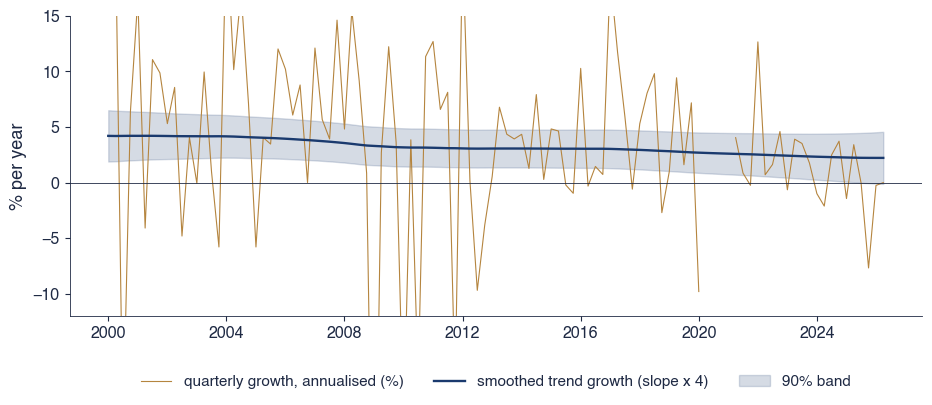

{'T': 106, 'first': '2000-01-01', 'last': '2026-04-01', 'par': [0.6012908346060548, 3.957698498021096, 0.003880141555111469], 'll': -231.07731965325206, 'sm_par': [0.6010815656065264, 3.9580882285949714, 0.0038804171615102138], 'sm_ll': -229.23984906736354, 'd': 2, 'g_at': {'2005-01-01': [4.059151786182848, 1.1298042670731994], '2012-01-01': [3.0764523531630497, 1.0350131690086737], '2019-01-01': [2.822799685040839, 1.0818968312714297]}, 'g_last': [2.223778898950282, 1.424046815814726]}


In [17]:
# Solution
r = b1_llt(save_it=False)
print(r)

**Interpretation of the result.** The bands overlap widely: a fall is suggested but not established.

## B2 [Proposed]: TVP regressions for Hungary and Poland

**Question.** Has the co-movement with euro-area inflation changed? Model: B1.

1. Estimate the TVP regression for each country.
2. Report $\hat\sigma^2_b$ and $b_t$ at three dates.
3. LR test of a constant slope.
4. Interpretation.

**Report:** a table of two rows, six slopes with standard errors, two tests, one sentence.

In [ ]:
# Your code here


## B3 [Solved]: stochastic volatility of EUR/RON

**Question.** How persistent is EUR/RON volatility, and how does SV compare with GARCH?

1. KSC Gibbs sampler (4,000 draws here; 20,000 on the slides).
2. GARCH(1,1).
3. Plot the volatilities.
4. Interpretation: the half-life.

**Report:** a table of three parameters, three GARCH numbers, one chart, one sentence.

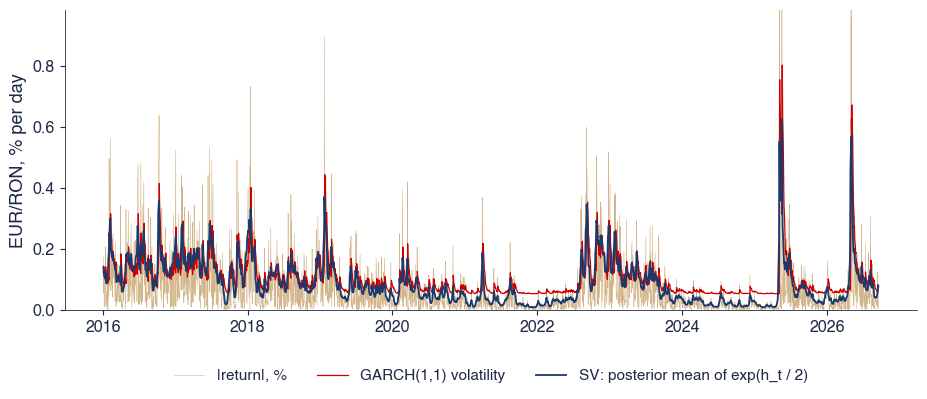

{'T': 2686, 'first': '2016-01-04', 'last': '2026-09-18', 'mean': [-5.625208834758784, 0.9566186859699523, 0.5440981389551163], 'lo': [-6.031503433478166, 0.9441817260488272, 0.4903408434567232], 'hi': [-5.210539528023605, 0.9680111116019074, 0.6006610737277931], 'ineff': [0.944706858774443, 15.436092469807038, 28.344949844425127], 'garch': [0.0007075474189213144, 0.224661761626979, 0.7525456994434221], 'll_garch': 2587.693362671933, 'kurt': 27.837915854735297, 'sd': 0.12132837800849494, 'half': 15.628877276051117, 'draws': 4000}


In [19]:
# Solution
r = b3_sv_eurron(save_it=False, draws=4000, burn=1000)
print(r)

**Interpretation of the result.** Very persistent volatility with rare bursts, typical of a managed float; the kurtosis calls for fatter tails.

## B4 [Proposed]: the particle filter for the EUR/RON SV model

**Question.** Is SV better than GARCH here, and is the particle likelihood reliable? Model: B3 and A7.

1. s.d. of the log-likelihood for $N = 500, 2000, 10000$.
2. Minimum and median ESS.
3. SV against GARCH.
4. Interpretation.

**Report:** three standard deviations, two ESS values and a date, two log-likelihoods, one sentence.

In [ ]:
# Your code here


## B5 [Proposed]: the Romanian output gap in real time

**Question.** How much does the end-of-sample gap change when later data arrive? Model: B1 and A10.

1. Real-time and final gaps.
2. Orphanides–van Norden statistics.
3. The largest revision.
4. Interpretation.

**Report:** four statistics, one number, one sentence.

In [ ]:
# Your code here


# Part C: open questions and AI critique

## C1 [Proposed]: is Romanian trend inflation anchored?

**Question.** Is the trend inside the BNR band (2.5% ± 1 pp), and how robust is the answer? Model: B3.

1. A five-line pre-registration.
2. UC-SV for start dates 2001 and 2006 and gamma = 0.1, 0.2.
3. Posterior probability of the band, last quarter and 2019Q4.
4. Interpretation and a project plan.

**Report:** a five-line plan, a table of four rows, a project plan.

In [ ]:
# Your code here


## C2 [Proposed]: audit an AI answer

**Context.** An AI assistant answered:

- (a) the Kalman filter is useless if the errors are not Gaussian;
- (b) for a random-walk state, set P1 = 10^10 and keep all n terms of the likelihood;
- (c) an ML estimate of the level variance equal to zero proves that the level is constant;
- (d) SV and GARCH are the same model, since both make volatility persistent;
- (e) the particle-filter likelihood is unbiased, so its logarithm is unbiased too;
- (f) the Durbin–Koopman simulation smoother needs only one state-smoother pass per draw;
- (g) with an AR(1) cycle, the correlation between trend and cycle shocks can be estimated.

1. For each statement, say whether it is correct; if not, give the correct statement and a number.

**Report:** seven verdicts with one line of justification each.

In [ ]:
# Your code here
